# Análisis Exploratorio de Datos (EDA)
## Clasificación Automática de Estadios del Sueño — Sleep-EDF (ST7242J0)
**Maestría en Inteligencia Artificial — Grupo 7**

Este notebook realiza el EDA completo sobre el registro de polisomnografía `ST7242J0`, enfocado en los canales de EEG (`Fpz-Cz` y `Pz-Oz`). Incluye:
1. Carga y preprocesamiento de señales
2. Distribución de clases y visualización del hipnograma
3. Visualización de señales crudas por estadio
4. Análisis espectral (PSD) por banda y por estadio
5. Estadísticas descriptivas por canal y estadio
6. Análisis de desbalance de clases

## 0. Instalación de dependencias

In [1]:
# Ejecutar solo si no están instaladas
# !pip install mne matplotlib seaborn scipy pandas numpy

## 1. Importaciones y configuración

In [1]:
import mne
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import signal as sp_signal
from scipy.stats import kurtosis, skew
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')
mne.set_log_level('WARNING')

# Estilo global
plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# Paleta de colores por estadio (consistente en todo el notebook)
STAGE_COLORS = {
    'W':   '#e74c3c',   # Rojo
    'N1':  '#f39c12',   # Naranja
    'N2':  '#3498db',   # Azul
    'N3':  '#2c3e50',   # Azul oscuro
    'REM': '#27ae60',   # Verde
    'M':   '#95a5a6',   # Gris
}
STAGE_ORDER = ['W', 'N1', 'N2', 'N3', 'REM', 'M']
# Rutas del dataset versionado con DVC.
# Se resuelve la raiz del repositorio para que el notebook funcione
# sin importar el directorio de trabajo. Si data/ no existe: dvc pull
def find_repo_root(start=None):
    start = (start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "data.dvc").exists():
            return candidate
    raise FileNotFoundError(
        "No se encontro la raiz del repositorio: falta data.dvc en los directorios padre"
    )

BASE      = find_repo_root() / "data" / "sleep-telemetry"
PSG_PATH  = BASE / "ST7242J0-PSG.edf"
HYPO_PATH = BASE / "ST7242JO-Hypnogram.edf"

print('Librerías cargadas correctamente ✓')

Librerías cargadas correctamente ✓


## 2. Carga de datos

In [2]:
# ── Cargar señales PSG ──────────────────────────────────────────────────────
raw = mne.io.read_raw_edf(PSG_PATH, preload=True, verbose=False)
raw.pick(['EEG Fpz-Cz', 'EEG Pz-Oz'])   # Solo canales EEG

sfreq    = raw.info['sfreq']             # 100 Hz
n_samples = raw.get_data().shape[1]
duration_h = n_samples / sfreq / 3600

print(f'Canales cargados : {raw.ch_names}')
print(f'Frecuencia       : {sfreq} Hz')
print(f'Duración         : {duration_h:.2f} horas ({n_samples} muestras)')

# ── Cargar anotaciones del hipnograma ───────────────────────────────────────
ann = mne.read_annotations(HYPO_PATH)

# Mapeo R&K → AASM
LABEL_MAP = {
    'Sleep stage W': 'W',
    'Sleep stage 1': 'N1',
    'Sleep stage 2': 'N2',
    'Sleep stage 3': 'N3',
    'Sleep stage 4': 'N3',   # Fusión 3+4 → N3
    'Sleep stage R': 'REM',
    'Movement time': 'M',
}

# Expandir anotaciones (cada una puede cubrir múltiples épocas de 30 s)
epoch_records = []
for desc, onset, dur in zip(ann.description, ann.onset, ann.duration):
    label = LABEL_MAP.get(desc, '?')
    n_ep  = int(round(dur / 30))
    for i in range(n_ep):
        epoch_records.append({
            'epoch_idx': len(epoch_records),
            'onset_s'  : onset + i * 30,
            'label'    : label,
            'rk_label' : desc,
        })

df_epochs = pd.DataFrame(epoch_records)

# Separar épocas válidas (excluir M y ?)
df_valid  = df_epochs[~df_epochs['label'].isin(['M', '?'])].reset_index(drop=True)
df_excl   = df_epochs[ df_epochs['label'].isin(['M', '?'])].reset_index(drop=True)

print(f'\nTotal épocas anotadas : {len(df_epochs)}')
print(f'Épocas válidas (AASM) : {len(df_valid)}')
print(f'Épocas excluidas (M/?) : {len(df_excl)}')
print('\nDistribución de clases:')
print(df_valid['label'].value_counts().reindex([s for s in STAGE_ORDER if s != 'M']))

Canales cargados : ['EEG Fpz-Cz', 'EEG Pz-Oz']
Frecuencia       : 100.0 Hz
Duración         : 8.19 horas (2948000 muestras)

Total épocas anotadas : 940
Épocas válidas (AASM) : 939
Épocas excluidas (M/?) : 1

Distribución de clases:
label
W       17
N1      22
N2     591
N3     139
REM    170
Name: count, dtype: int64


## 3. Hipnograma — arquitectura del sueño

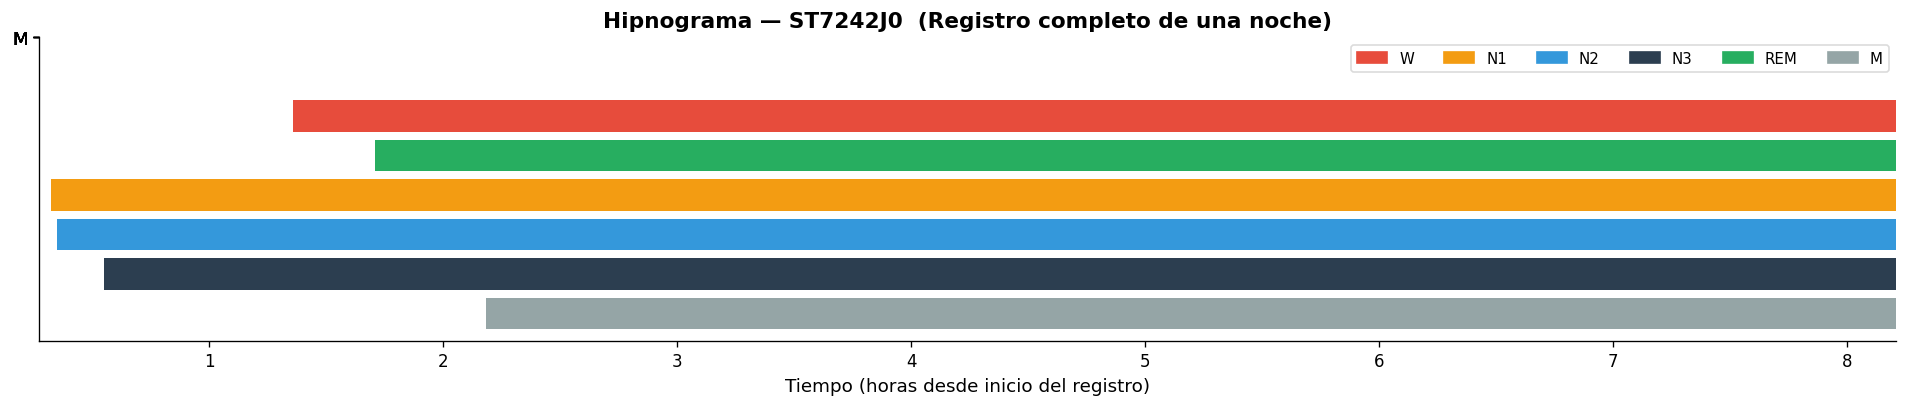

Hipnograma guardado ✓


In [4]:
# Mapa numérico para el eje Y del hipnograma
STAGE_Y = {'W': 5, 'REM': 4, 'N1': 3, 'N2': 2, 'N3': 1, 'M': 0}

fig, ax = plt.subplots(figsize=(16, 3.5))

for _, row in df_epochs.iterrows():
    lbl = row['label']
    y   = STAGE_Y.get(lbl, 0)
    col = STAGE_COLORS.get(lbl, '#95a5a6')
    ax.barh(y, 30, left=row['onset_s'] / 3600, height=0.8,
            color=col, linewidth=0)

#ax.set_yticks(list(STAGE_Y.values()))
ax.set_yticks([7, 7, 7, 7, 7, 7])
ax.set_yticklabels(list(STAGE_Y.keys()), fontsize=11)
ax.set_xlabel('Tiempo (horas desde inicio del registro)', fontsize=11)
ax.set_title('Hipnograma — ST7242J0  (Registro completo de una noche)', fontsize=13, fontweight='bold')

# Leyenda
patches = [mpatches.Patch(color=STAGE_COLORS[s], label=s)
           for s in ['W', 'N1', 'N2', 'N3', 'REM', 'M']]
ax.legend(handles=patches, loc='upper right', ncol=6, fontsize=9,
          framealpha=0.7)

ax.set_xlim(df_epochs['onset_s'].min() / 3600 - 0.05,
            (df_epochs['onset_s'].max() + 30) / 3600 + 0.05)
plt.tight_layout()
plt.savefig('hipnograma_ST7242J0.png', bbox_inches='tight')
plt.show()
print('Hipnograma guardado ✓')

## 4. Distribución de clases

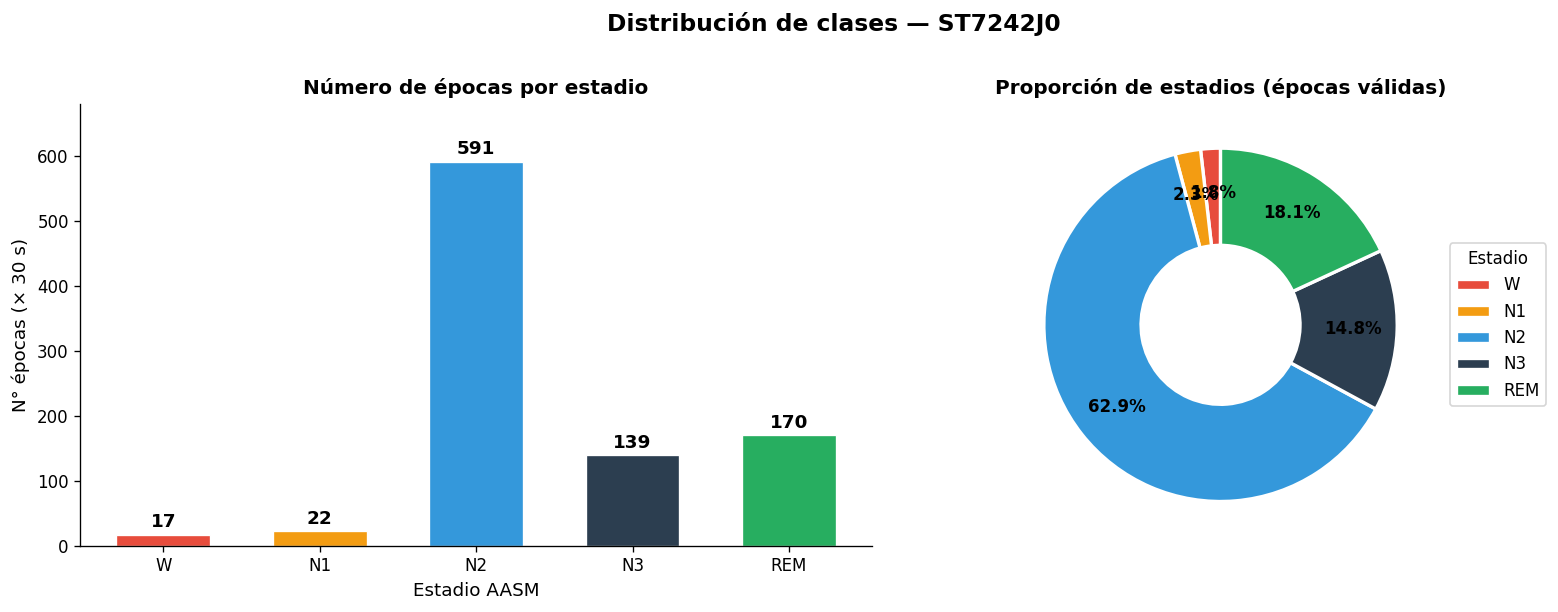


Estadio  Épocas  Tiempo (min)  Proporción (%)
      W      17           8.5             1.8
     N1      22          11.0             2.3
     N2     591         295.5            62.9
     N3     139          69.5            14.8
    REM     170          85.0            18.1

Total: 939 épocas válidas | 7.83 horas de sueño útil
Épocas excluidas (M): 1


In [5]:
valid_stages = [s for s in STAGE_ORDER if s != 'M']
counts = df_valid['label'].value_counts().reindex(valid_stages).fillna(0).astype(int)
props  = counts / counts.sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Barras absolutas ──
bars = axes[0].bar(valid_stages,
                   [counts[s] for s in valid_stages],
                   color=[STAGE_COLORS[s] for s in valid_stages],
                   edgecolor='white', linewidth=0.8, width=0.6)
for bar, cnt in zip(bars, [counts[s] for s in valid_stages]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 str(cnt), ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[0].set_title('Número de épocas por estadio', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Estadio AASM', fontsize=11)
axes[0].set_ylabel('N° épocas (× 30 s)', fontsize=11)
axes[0].set_ylim(0, counts.max() * 1.15)

# ── Pie chart ──
wedge_props = dict(width=0.55, edgecolor='white', linewidth=2)
wedges, texts, autotexts = axes[1].pie(
    [counts[s] for s in valid_stages],
    labels=None,
    colors=[STAGE_COLORS[s] for s in valid_stages],
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops=wedge_props,
    pctdistance=0.75
)
for at in autotexts:
    at.set_fontsize(10)
    at.set_fontweight('bold')
axes[1].legend(wedges, valid_stages, title='Estadio',
               loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize=10)
axes[1].set_title('Proporción de estadios (épocas válidas)', fontsize=12, fontweight='bold')

plt.suptitle('Distribución de clases — ST7242J0', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('distribucion_clases_ST7242J0.png', bbox_inches='tight')
plt.show()

# ── Tabla resumen ──
summary = pd.DataFrame({
    'Estadio': valid_stages,
    'Épocas' : [counts[s] for s in valid_stages],
    'Tiempo (min)': [counts[s] * 0.5 for s in valid_stages],
    'Proporción (%)': [round(props[s], 1) for s in valid_stages],
})
print('\n' + summary.to_string(index=False))
print(f'\nTotal: {counts.sum()} épocas válidas | {counts.sum()*30/3600:.2f} horas de sueño útil')
print(f'Épocas excluidas (M): {len(df_excl)}')

## 5. Visualización de señales crudas por estadio

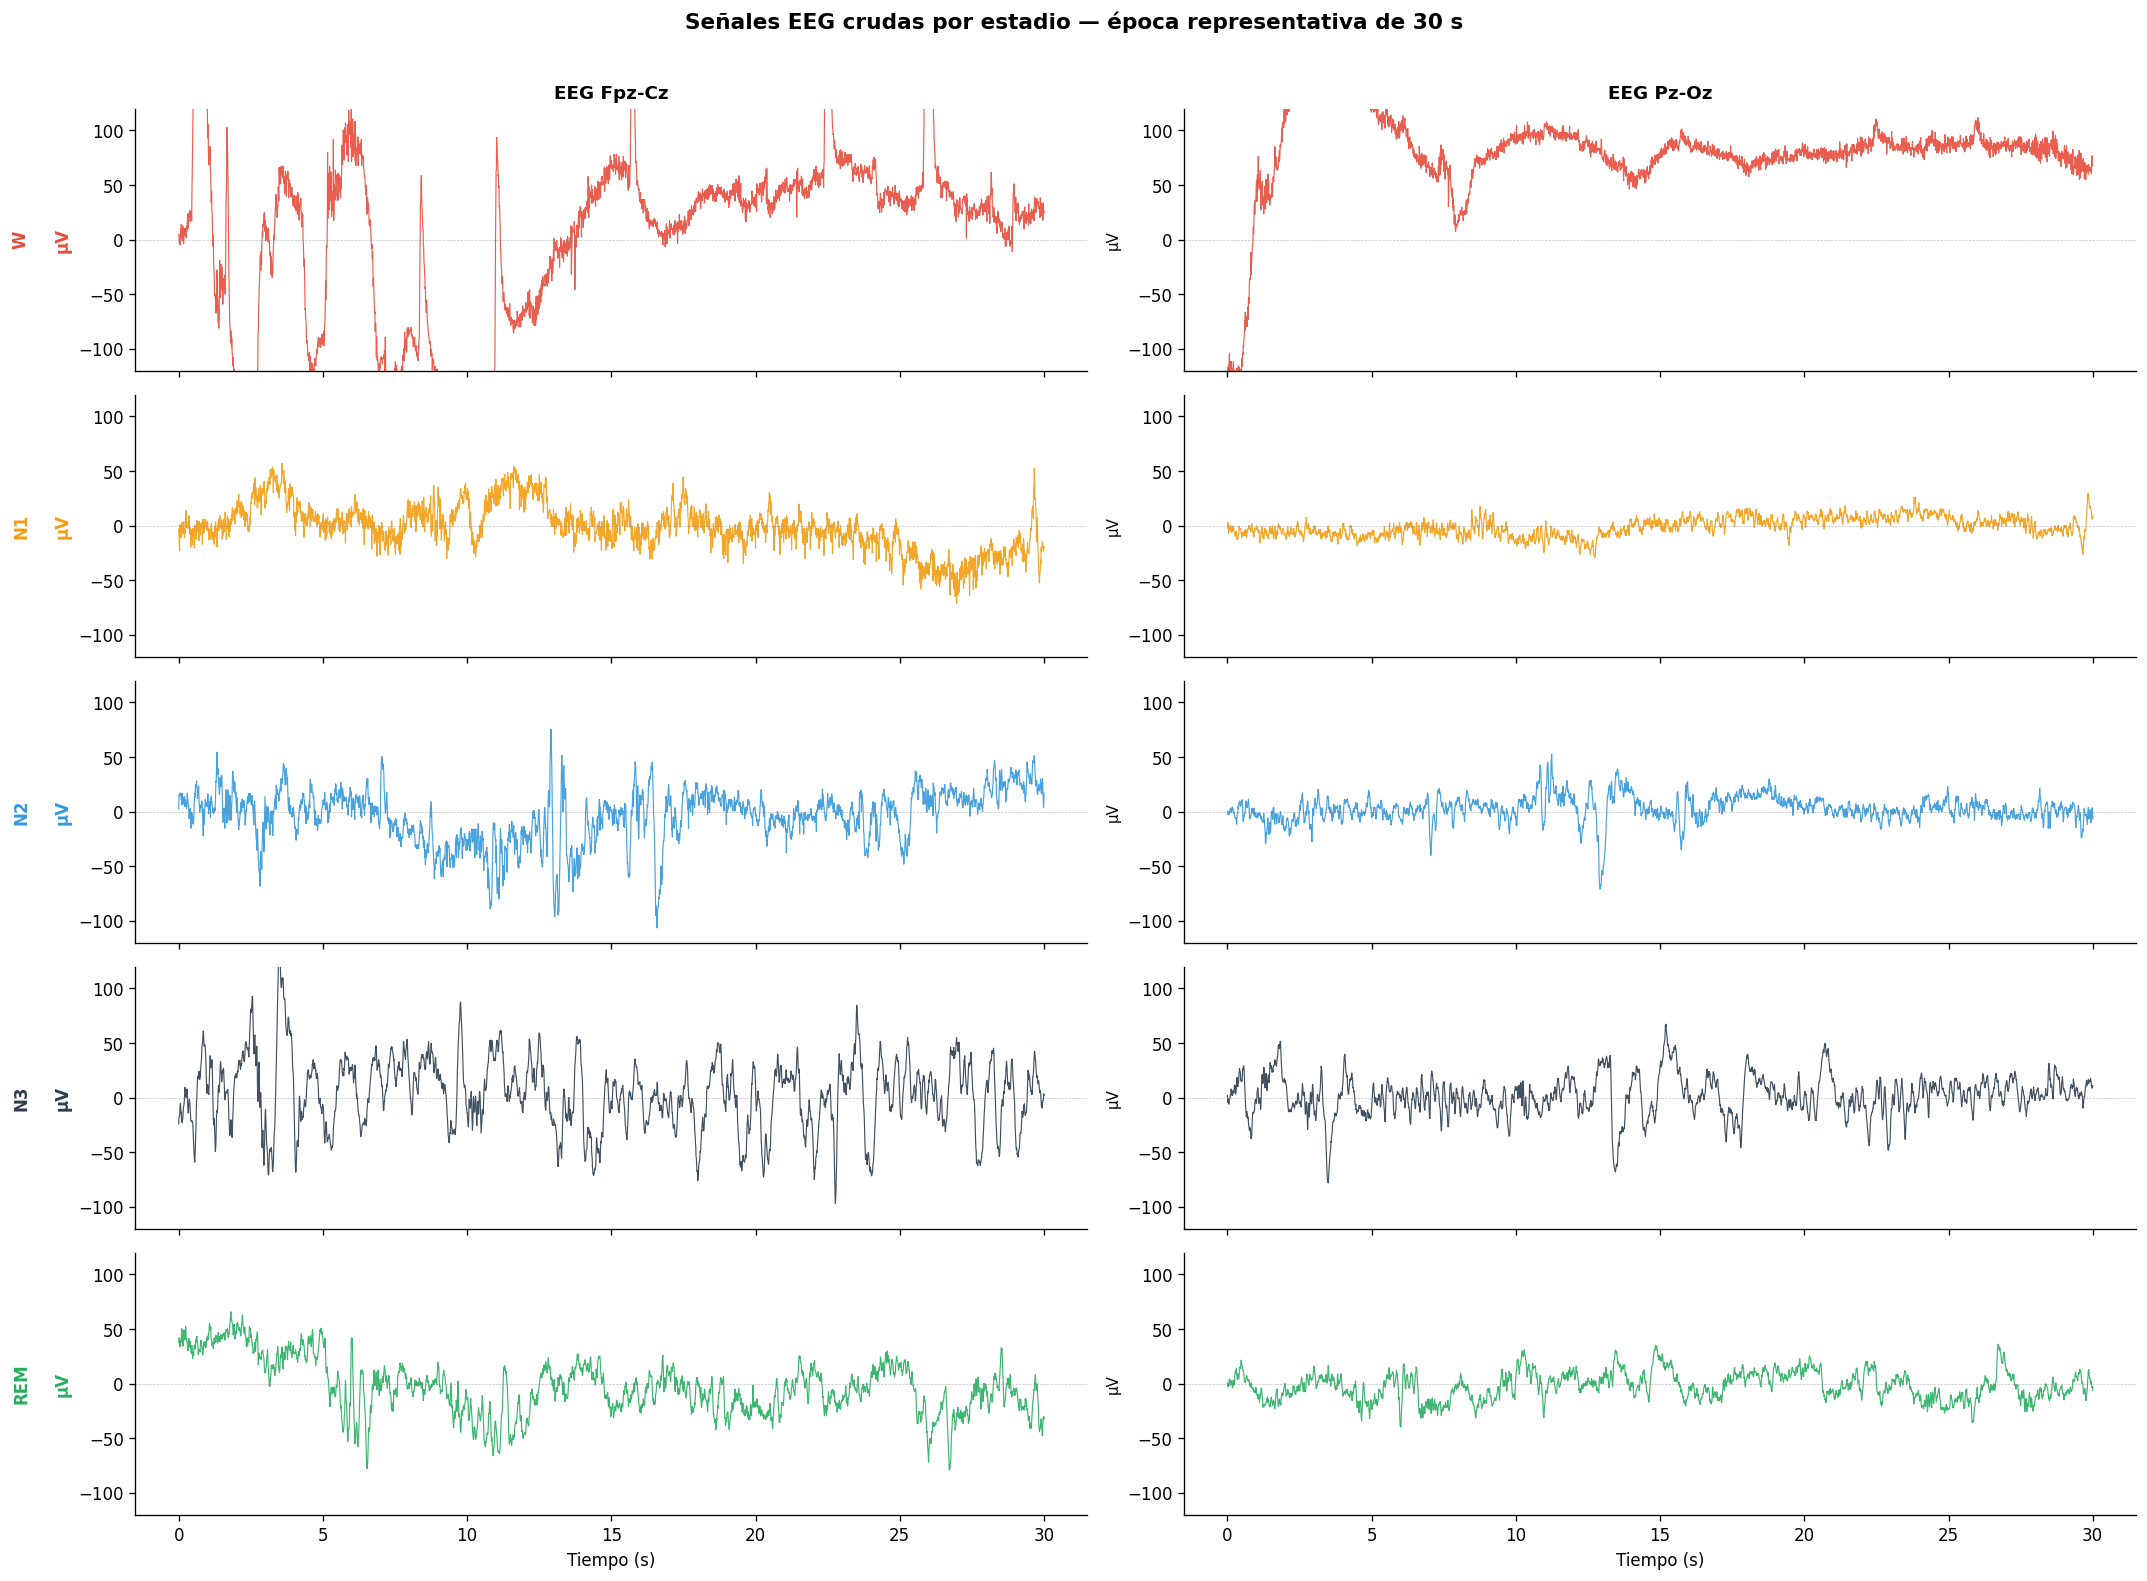

Señales crudas guardadas ✓


In [6]:
def get_epoch_data(onset_s, raw, sfreq, duration=30):
    """Extrae datos de una época dada su onset en segundos."""
    start = int(onset_s * sfreq)
    stop  = start + int(duration * sfreq)
    stop  = min(stop, raw.get_data().shape[1])
    return raw.get_data(start=start, stop=stop) * 1e6  # Convertir a µV

def pick_representative_epoch(df_valid, stage, raw, sfreq, n_candidates=5):
    """Selecciona la época más representativa (menor varianza extrema) de un estadio."""
    candidates = df_valid[df_valid['label'] == stage].head(n_candidates)
    best, best_var = None, np.inf
    for _, row in candidates.iterrows():
        data = get_epoch_data(row['onset_s'], raw, sfreq)
        v = np.var(data)
        if v < best_var:
            best_var = v
            best = (row['onset_s'], data)
    return best

stages_to_plot = [s for s in STAGE_ORDER if s in df_valid['label'].values and s != 'M']
channels = ['EEG Fpz-Cz', 'EEG Pz-Oz']
t = np.linspace(0, 30, int(30 * sfreq))

fig, axes = plt.subplots(len(stages_to_plot), 2,
                          figsize=(18, len(stages_to_plot) * 2.6),
                          sharex=True)

for i, stage in enumerate(stages_to_plot):
    onset, data = pick_representative_epoch(df_valid, stage, raw, sfreq)
    for j, ch_name in enumerate(channels):
        ax = axes[i][j]
        signal = data[j][:len(t)]
        ax.plot(t, signal, color=STAGE_COLORS[stage], linewidth=0.7, alpha=0.9)
        ax.axhline(0, color='gray', linewidth=0.4, linestyle='--', alpha=0.5)
        ax.set_ylabel('µV', fontsize=9)
        ax.set_ylim(-120, 120)
        if i == 0:
            ax.set_title(ch_name, fontsize=11, fontweight='bold')
        if i == len(stages_to_plot) - 1:
            ax.set_xlabel('Tiempo (s)', fontsize=10)
        # Etiqueta del estadio en el margen izquierdo
        if j == 0:
            ax.set_ylabel(f'{stage}\n\nµV', fontsize=10, fontweight='bold',
                          color=STAGE_COLORS[stage])

plt.suptitle('Señales EEG crudas por estadio — época representativa de 30 s',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('senales_crudas_por_estadio.png', bbox_inches='tight')
plt.show()
print('Señales crudas guardadas ✓')

## 6. Análisis espectral (PSD) por estadio

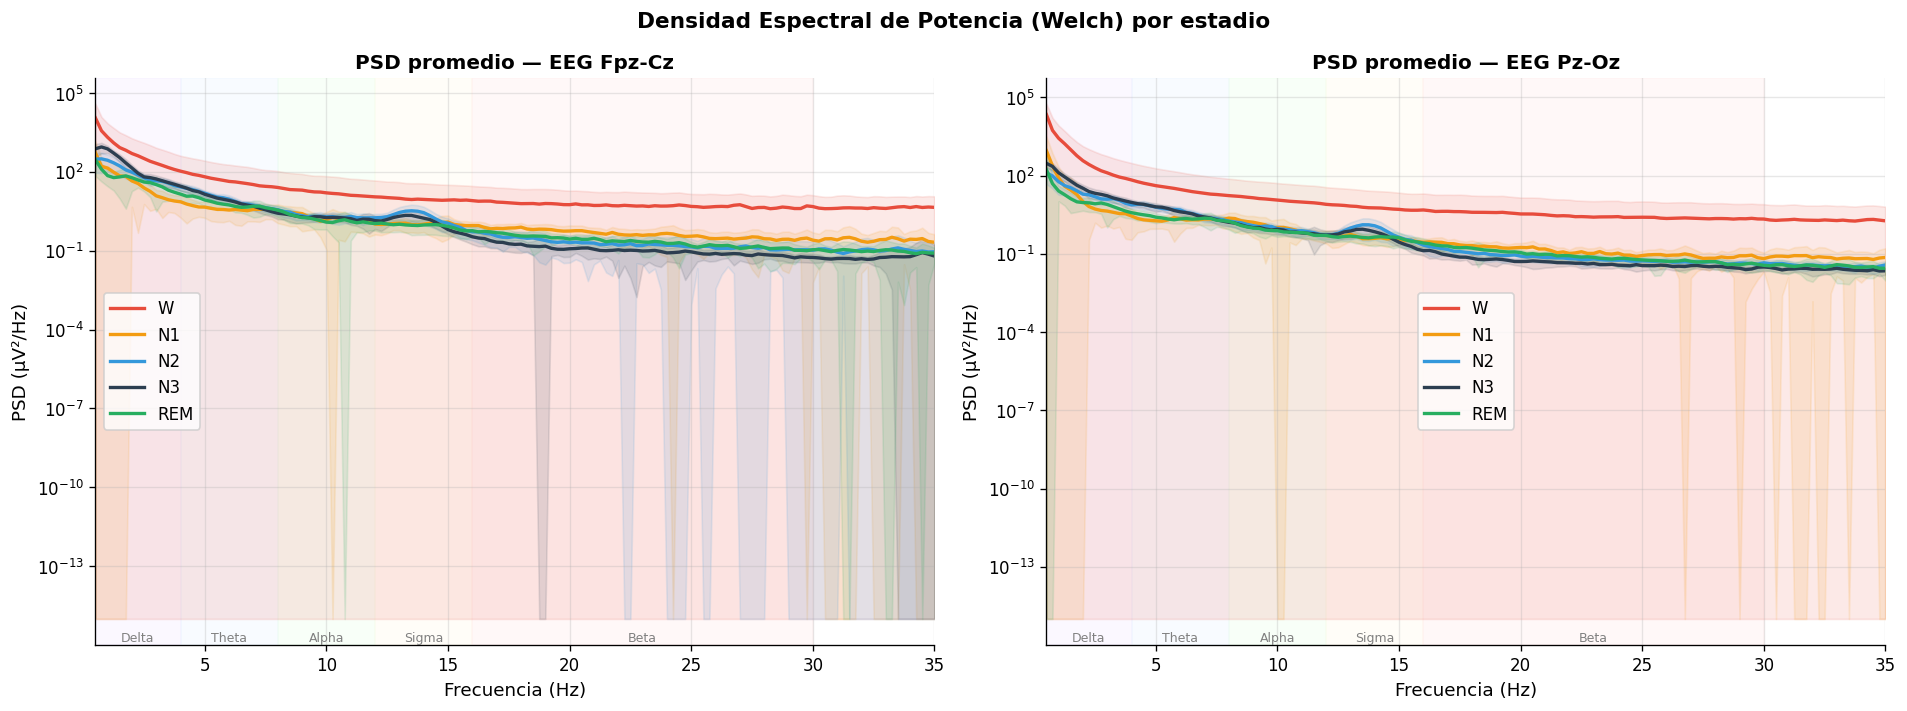

PSD guardado ✓


In [7]:
# Bandas de frecuencia estándar EEG
BANDS = {
    'Delta\n(0.5–4 Hz)'  : (0.5, 4),
    'Theta\n(4–8 Hz)'    : (4,   8),
    'Alpha\n(8–12 Hz)'   : (8,  12),
    'Sigma\n(12–16 Hz)'  : (12, 16),
    'Beta\n(16–30 Hz)'   : (16, 30),
}

def compute_psd_epoch(data_1d, sfreq, fmin=0.5, fmax=35):
    """Calcula PSD de una época con Welch."""
    nperseg = min(int(sfreq * 4), len(data_1d))
    freqs, psd = sp_signal.welch(data_1d, fs=sfreq, nperseg=nperseg,
                                  noverlap=nperseg // 2)
    mask = (freqs >= fmin) & (freqs <= fmax)
    return freqs[mask], psd[mask]

def bandpower(freqs, psd, fmin, fmax):
    """Potencia de banda por integración trapezoidal."""
    mask = (freqs >= fmin) & (freqs <= fmax)
    return np.trapezoid(psd[mask], freqs[mask])

# ── Calcular PSD promedio por estadio (hasta 30 épocas por clase) ──────────
MAX_EPOCHS_PER_STAGE = 30
psd_by_stage = {s: {ch: [] for ch in channels} for s in stages_to_plot}

for stage in stages_to_plot:
    subset = df_valid[df_valid['label'] == stage].head(MAX_EPOCHS_PER_STAGE)
    for _, row in subset.iterrows():
        data = get_epoch_data(row['onset_s'], raw, sfreq)
        for j, ch in enumerate(channels):
            freqs, psd = compute_psd_epoch(data[j], sfreq)
            psd_by_stage[stage][ch].append(psd)

# ── Plot PSD promedio ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=False)

for j, ch in enumerate(channels):
    ax = axes[j]
    for stage in stages_to_plot:
        psds = np.array(psd_by_stage[stage][ch])
        if len(psds) == 0:
            continue
        mean_psd = psds.mean(axis=0)
        std_psd  = psds.std(axis=0)
        ax.semilogy(freqs, mean_psd, label=stage,
                    color=STAGE_COLORS[stage], linewidth=2)
        ax.fill_between(freqs,
                        np.maximum(mean_psd - std_psd, 1e-15),
                        mean_psd + std_psd,
                        color=STAGE_COLORS[stage], alpha=0.12)

    # Sombrear bandas
    band_colors = ['#f0e6ff', '#e6f3ff', '#e6ffe6', '#fff9e6', '#ffe6e6']
    for (band_name, (f1, f2)), bc in zip(BANDS.items(), band_colors):
        ax.axvspan(f1, f2, alpha=0.25, color=bc, zorder=0)
        ax.text((f1+f2)/2, ax.get_ylim()[0] if ax.get_ylim()[0] > 0 else 1e-14,
                band_name.split('\n')[0], ha='center', va='bottom',
                fontsize=7.5, color='gray')

    ax.set_xlabel('Frecuencia (Hz)', fontsize=11)
    ax.set_ylabel('PSD (µV²/Hz)', fontsize=11)
    ax.set_title(f'PSD promedio — {ch}', fontsize=12, fontweight='bold')
    ax.set_xlim(0.5, 35)
    ax.legend(fontsize=10, framealpha=0.8)
    ax.grid(True, alpha=0.3, which='both')

plt.suptitle('Densidad Espectral de Potencia (Welch) por estadio',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('PSD_por_estadio.png', bbox_inches='tight')
plt.show()
print('PSD guardado ✓')

## 7. Potencia de banda por estadio (heatmap)

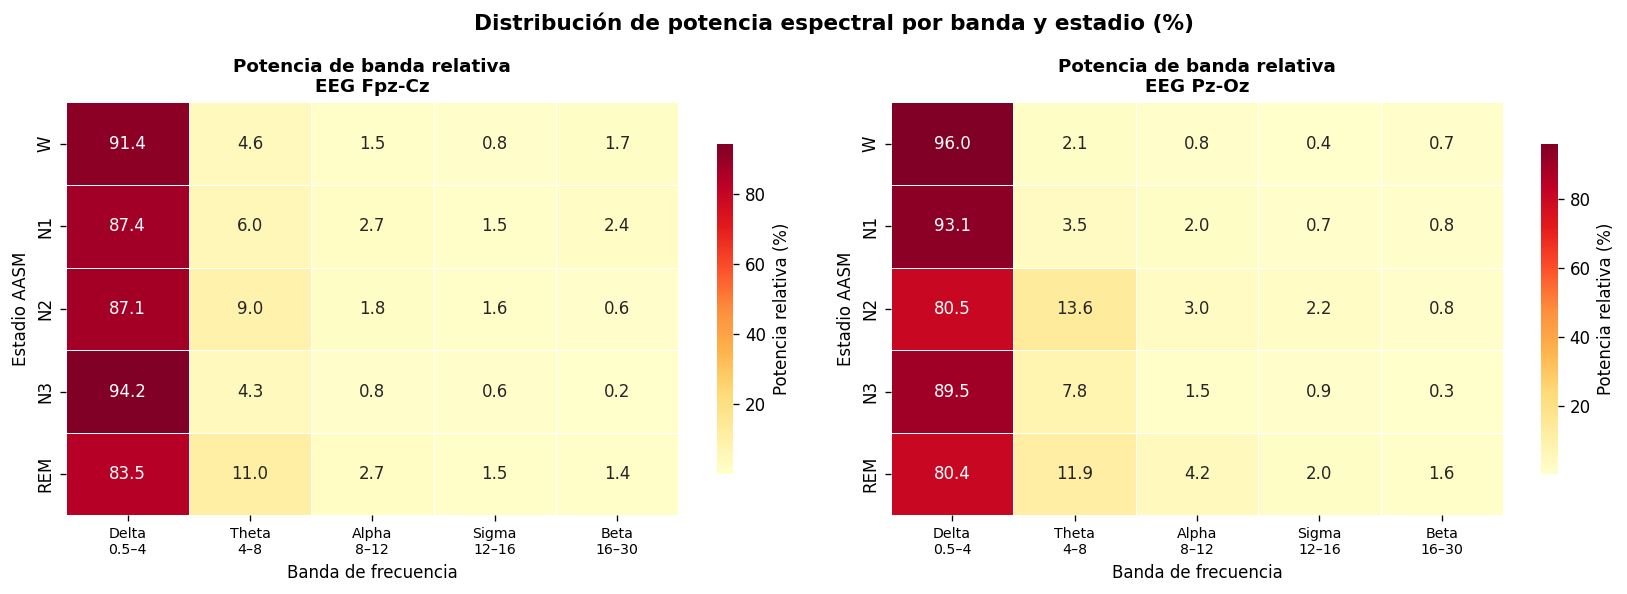

Heatmap guardado ✓


In [8]:
band_names_short = ['Delta\n0.5–4', 'Theta\n4–8', 'Alpha\n8–12', 'Sigma\n12–16', 'Beta\n16–30']
band_ranges      = list(BANDS.values())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for j, ch in enumerate(channels):
    # Matriz: estadios × bandas (potencia media relativa en %)
    mat = np.zeros((len(stages_to_plot), len(band_ranges)))
    for i, stage in enumerate(stages_to_plot):
        psds = np.array(psd_by_stage[stage][ch])
        if len(psds) == 0:
            continue
        mean_psd = psds.mean(axis=0)
        total    = sum(bandpower(freqs, mean_psd, f1, f2) for f1, f2 in band_ranges)
        for k, (f1, f2) in enumerate(band_ranges):
            mat[i, k] = bandpower(freqs, mean_psd, f1, f2) / total * 100

    df_heat = pd.DataFrame(mat, index=stages_to_plot, columns=band_names_short)
    sns.heatmap(df_heat, ax=axes[j], annot=True, fmt='.1f',
                cmap='YlOrRd', linewidths=0.5,
                cbar_kws={'label': 'Potencia relativa (%)', 'shrink': 0.8},
                annot_kws={'size': 10})
    axes[j].set_title(f'Potencia de banda relativa\n{ch}',
                      fontsize=11, fontweight='bold')
    axes[j].set_ylabel('Estadio AASM', fontsize=10)
    axes[j].set_xlabel('Banda de frecuencia', fontsize=10)
    axes[j].tick_params(axis='x', labelsize=8.5)

plt.suptitle('Distribución de potencia espectral por banda y estadio (%)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('heatmap_bandas_estadio.png', bbox_inches='tight')
plt.show()
print('Heatmap guardado ✓')

## 8. Estadísticas descriptivas de señales crudas por estadio

In [9]:
MAX_STAT_EPOCHS = 20

stat_records = []
for stage in stages_to_plot:
    subset = df_valid[df_valid['label'] == stage].head(MAX_STAT_EPOCHS)
    for _, row in subset.iterrows():
        data = get_epoch_data(row['onset_s'], raw, sfreq)
        for j, ch in enumerate(channels):
            sig = data[j]
            stat_records.append({
                'Estadio': stage,
                'Canal'  : ch,
                'Media (µV)'    : np.mean(sig),
                'Std (µV)'      : np.std(sig),
                'Rango pico-pico': np.ptp(sig),
                'Kurtosis'      : kurtosis(sig),
                'Skewness'      : skew(sig),
                'RMS (µV)'      : np.sqrt(np.mean(sig**2)),
            })

df_stats = pd.DataFrame(stat_records)
df_summary = df_stats.groupby(['Estadio', 'Canal']).mean().round(3)
print('=== Estadísticas descriptivas promedio por estadio y canal ===\n')
print(df_summary.to_string())

=== Estadísticas descriptivas promedio por estadio y canal ===

                    Media (µV)  Std (µV)  Rango pico-pico  Kurtosis  Skewness  RMS (µV)
Estadio Canal                                                                          
N1      EEG Fpz-Cz       3.628    48.298          267.698     1.563    -0.670    52.482
        EEG Pz-Oz       -1.481    65.180          308.185     1.819     0.248    75.481
N2      EEG Fpz-Cz      -0.015    25.102          186.010     1.043    -0.492    25.628
        EEG Pz-Oz        0.309    13.460           99.799     1.238    -0.044    13.684
N3      EEG Fpz-Cz      -0.420    36.830          255.118     1.006    -0.499    37.037
        EEG Pz-Oz        0.429    19.280          129.683     0.597    -0.177    19.520
REM     EEG Fpz-Cz       0.236    33.754          207.966     1.669    -0.799    34.378
        EEG Pz-Oz        0.651    28.308          146.493     0.763     0.139    32.174
W       EEG Fpz-Cz     -77.722   206.801          823.61

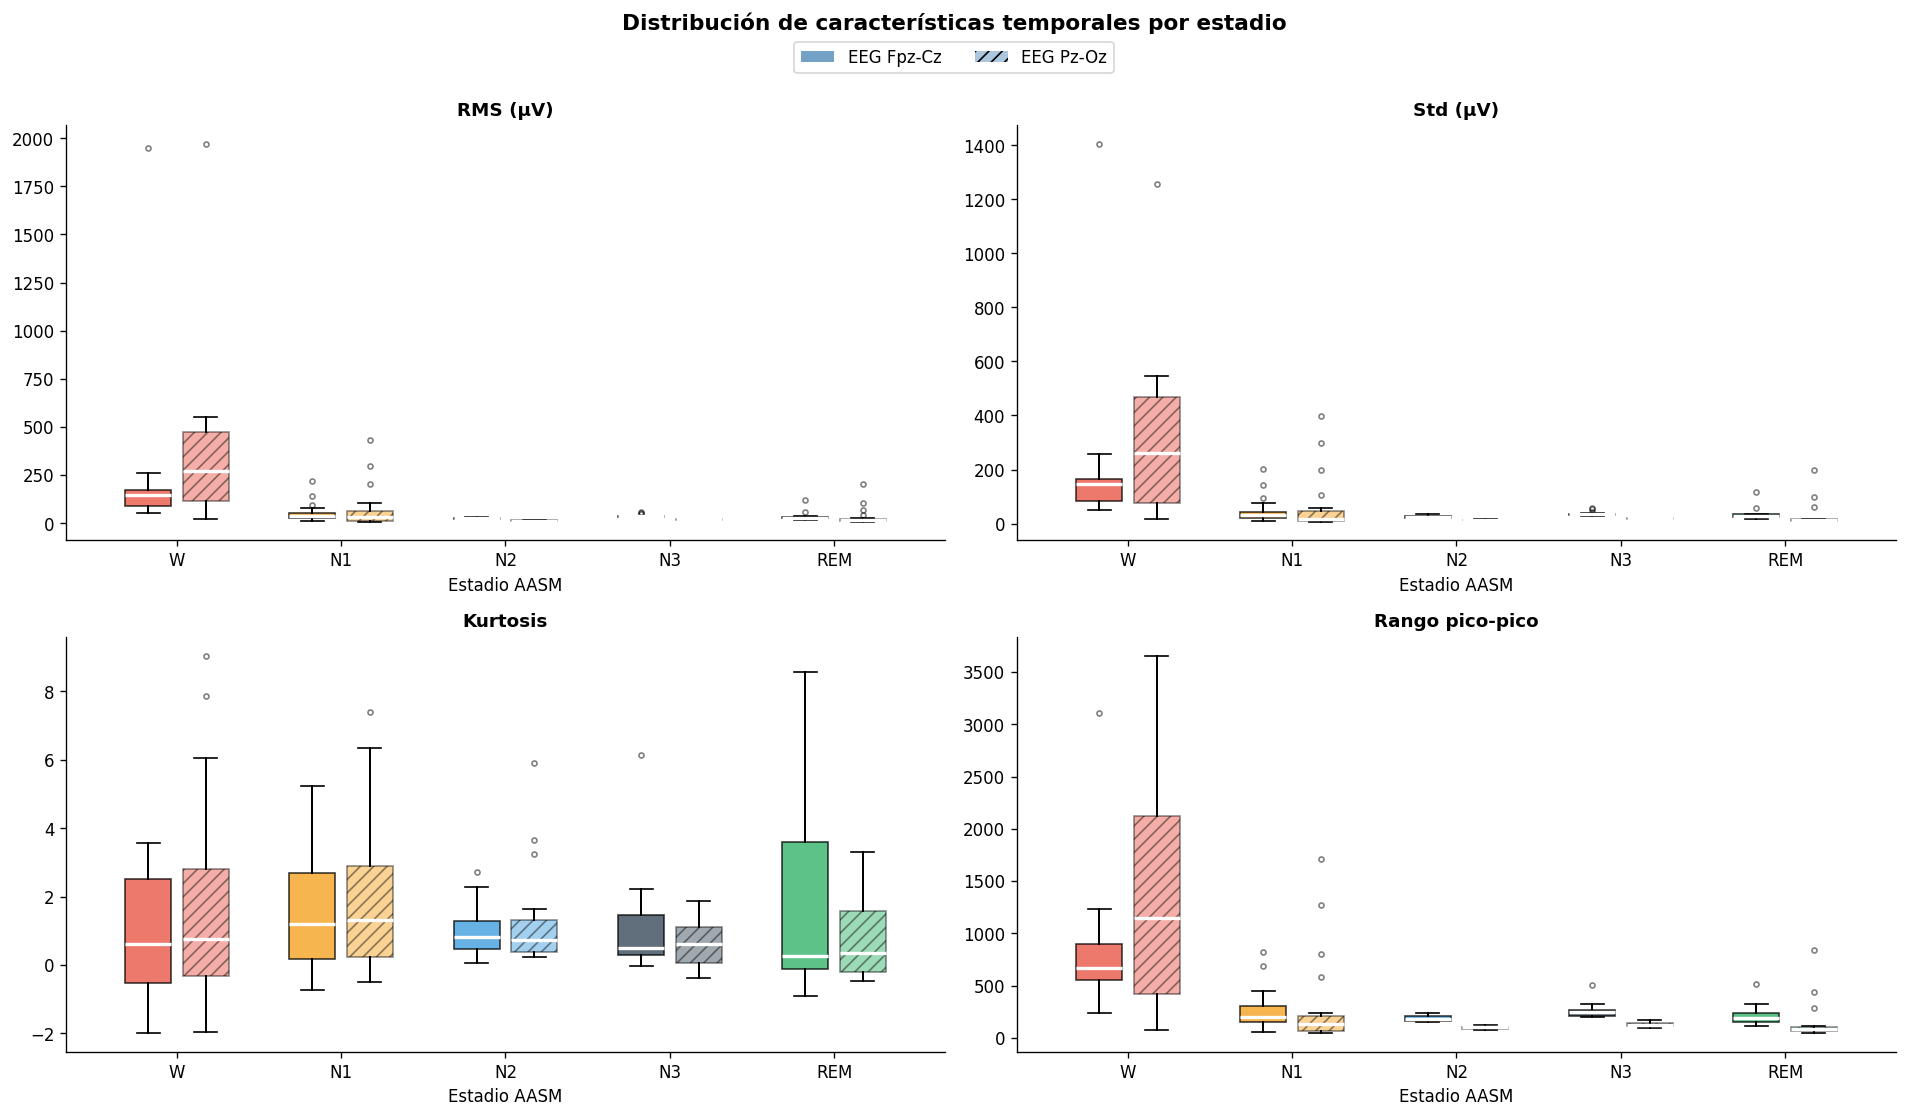

Boxplots guardados ✓


In [10]:
# ── Boxplots de RMS y Std por estadio ────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 9))
metrics = ['RMS (µV)', 'Std (µV)', 'Kurtosis', 'Rango pico-pico']

for ax, metric in zip(axes.flatten(), metrics):
    for j, ch in enumerate(channels):
        sub = df_stats[df_stats['Canal'] == ch]
        stage_vals = [sub[sub['Estadio'] == s][metric].values
                      for s in stages_to_plot]
        positions = np.arange(len(stages_to_plot)) + j * 0.35
        bp = ax.boxplot(stage_vals, positions=positions, widths=0.28,
                        patch_artist=True, notch=False,
                        medianprops=dict(color='white', linewidth=2),
                        whiskerprops=dict(linewidth=1.2),
                        flierprops=dict(marker='o', markersize=3, alpha=0.5))
        for patch, stage in zip(bp['boxes'], stages_to_plot):
            patch.set_facecolor(STAGE_COLORS[stage])
            patch.set_alpha(0.75 if j == 0 else 0.45)
            if j == 1:
                patch.set_hatch('///')

    ax.set_xticks(np.arange(len(stages_to_plot)) + 0.175)
    ax.set_xticklabels(stages_to_plot, fontsize=10)
    ax.set_title(metric, fontsize=11, fontweight='bold')
    ax.set_xlabel('Estadio AASM', fontsize=10)

# Leyenda canales
from matplotlib.lines import Line2D
legend_elements = [
    mpatches.Patch(facecolor='steelblue', alpha=0.75, label='EEG Fpz-Cz'),
    mpatches.Patch(facecolor='steelblue', alpha=0.45, hatch='///', label='EEG Pz-Oz'),
]
fig.legend(handles=legend_elements, loc='upper center',
           ncol=2, fontsize=10, bbox_to_anchor=(0.5, 1.01))

plt.suptitle('Distribución de características temporales por estadio',
             fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('boxplots_estadisticas.png', bbox_inches='tight')
plt.show()
print('Boxplots guardados ✓')

## 9. Análisis de desbalance de clases

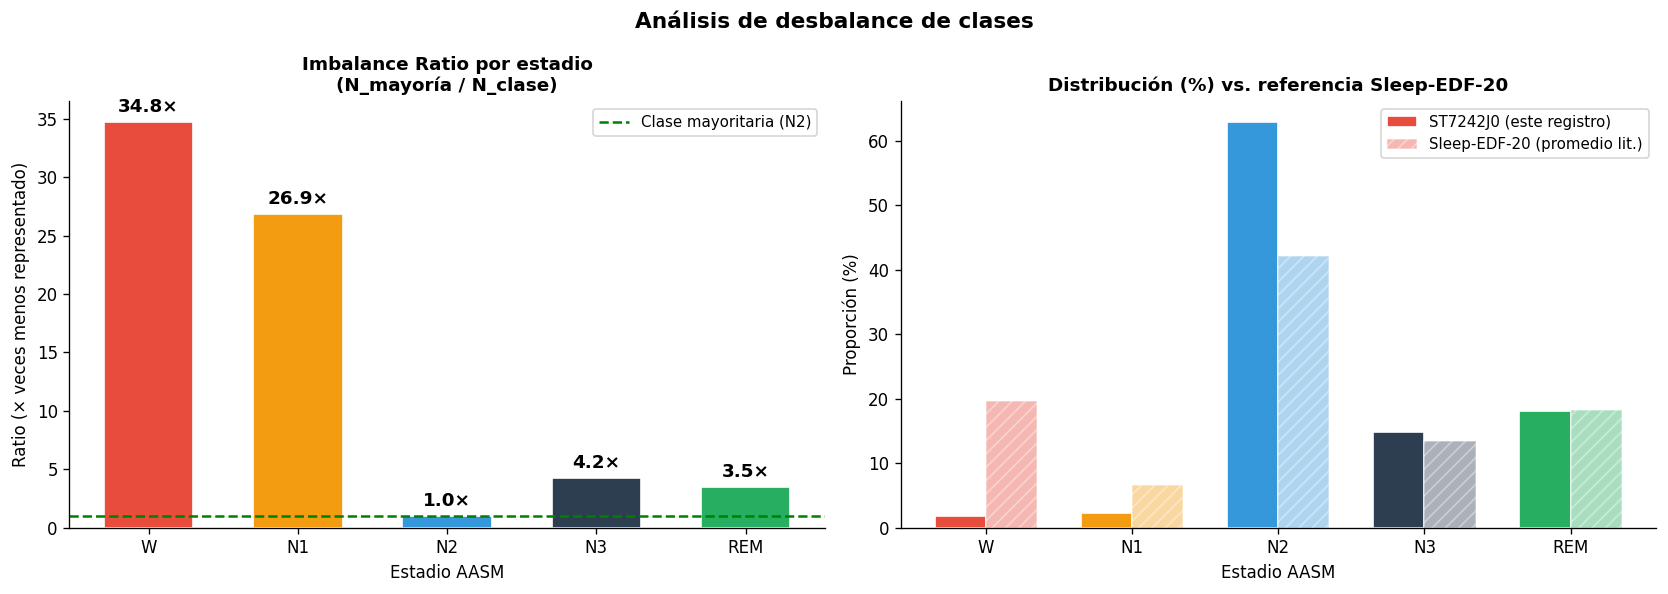


=== Imbalance Ratio (IR) ===
(La clase N2 es la mayoritaria en este registro)
  W  :  34.8× menos épocas que N2
  N1 :  26.9× menos épocas que N2
  N2 :   1.0× menos épocas que N2
  N3 :   4.2× menos épocas que N2
  REM:   3.5× menos épocas que N2


In [11]:
counts_valid = df_valid['label'].value_counts().reindex(
    [s for s in STAGE_ORDER if s != 'M']).fillna(0)
n_majority = counts_valid.max()
ir = (n_majority / counts_valid).round(2)  # Imbalance Ratio

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Imbalance Ratio ──
colors_ir = [STAGE_COLORS[s] for s in ir.index]
bars = axes[0].bar(ir.index, ir.values, color=colors_ir,
                   edgecolor='white', width=0.6)
for bar, val in zip(bars, ir.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 f'{val:.1f}×', ha='center', va='bottom',
                 fontsize=11, fontweight='bold')
axes[0].axhline(1, color='green', linestyle='--', linewidth=1.5,
                label='Clase mayoritaria (N2)')
axes[0].set_title('Imbalance Ratio por estadio\n(N_mayoría / N_clase)',
                  fontsize=11, fontweight='bold')
axes[0].set_xlabel('Estadio AASM', fontsize=10)
axes[0].set_ylabel('Ratio (× veces menos representado)', fontsize=10)
axes[0].legend(fontsize=9)

# ── Comparativa con Sleep-EDF-20 promedio (referencia literatura) ──
# Valores aproximados reportados en Supratak et al. 2017 para SC-20
ref_counts = {'W': 8285, 'N1': 2804, 'N2': 17799, 'N3': 5703, 'REM': 7717}
ref_total = sum(ref_counts.values())
ref_pct = {k: v/ref_total*100 for k, v in ref_counts.items()}
our_pct = (counts_valid / counts_valid.sum() * 100).to_dict()

x = np.arange(len([s for s in STAGE_ORDER if s not in ['M','?']]))
stage_labels = [s for s in STAGE_ORDER if s not in ['M','?']]
w = 0.35
b1 = axes[1].bar(x - w/2,
                 [our_pct.get(s, 0) for s in stage_labels],
                 width=w, label='ST7242J0 (este registro)',
                 color=[STAGE_COLORS[s] for s in stage_labels],
                 edgecolor='white')
b2 = axes[1].bar(x + w/2,
                 [ref_pct.get(s, 0) for s in stage_labels],
                 width=w, label='Sleep-EDF-20 (promedio lit.)',
                 color=[STAGE_COLORS[s] for s in stage_labels],
                 edgecolor='white', alpha=0.4, hatch='///')
axes[1].set_xticks(x)
axes[1].set_xticklabels(stage_labels, fontsize=10)
axes[1].set_title('Distribución (%) vs. referencia Sleep-EDF-20',
                  fontsize=11, fontweight='bold')
axes[1].set_xlabel('Estadio AASM', fontsize=10)
axes[1].set_ylabel('Proporción (%)', fontsize=10)
axes[1].legend(fontsize=9)

plt.suptitle('Análisis de desbalance de clases', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('desbalance_clases.png', bbox_inches='tight')
plt.show()

print('\n=== Imbalance Ratio (IR) ===')
print('(La clase N2 es la mayoritaria en este registro)')
for s in ir.index:
    print(f'  {s:3s}: {ir[s]:5.1f}× menos épocas que N2')

## 10. Resumen y conclusiones del EDA

In [12]:
print('=' * 65)
print('   RESUMEN EDA — ST7242J0 (Sleep-EDF Telemetry)')
print('=' * 65)

print(f"""
SUJETO
  Archivo   : ST7242J0-PSG.edf
  Paciente  : Mujer, 48 años (X F X Female_48yr)
  Grabación : 15-Sep-1994
  Duración  : {duration_h:.2f} horas

SEÑALES
  Canales EEG : Fpz-Cz, Pz-Oz
  Fs          : {sfreq:.0f} Hz
  Resolución  : 30 000 muestras / época

ÉPOCAS
  Total anotadas : {len(df_epochs)}
  Válidas (AASM) : {len(df_valid)}  ({len(df_valid)/len(df_epochs)*100:.1f}%)
  Excluidas (M)  : {len(df_excl)}

DISTRIBUCIÓN DE CLASES
  N2  = {counts_valid.get('N2',0):4d} épocas ({counts_valid.get('N2',0)/len(df_valid)*100:.1f}%)  ← CLASE MAYORITARIA
  REM = {counts_valid.get('REM',0):4d} épocas ({counts_valid.get('REM',0)/len(df_valid)*100:.1f}%)
  N3  = {counts_valid.get('N3',0):4d} épocas ({counts_valid.get('N3',0)/len(df_valid)*100:.1f}%)
  N1  = {counts_valid.get('N1',0):4d} épocas ({counts_valid.get('N1',0)/len(df_valid)*100:.1f}%)  ← MÁS DIFÍCIL
  W   = {counts_valid.get('W',0):4d} épocas ({counts_valid.get('W',0)/len(df_valid)*100:.1f}%)

OBSERVACIONES CLAVE
  1. Desbalance severo: N2 es ~{counts_valid.get('N2',0)//max(counts_valid.get('N1',1),1)}x más frecuente que N1.
     → Usar F1-macro como métrica principal, no accuracy.
     → Evaluar class_weight='balanced' en modelos clásicos.

  2. N3 tiene alta potencia delta (0.5-4 Hz) muy característica.
     REM tiene patrón mixto de frecuencias similar a vigilia.

  3. Este sujeto tiene perfil inusual: muy poco W (no hay
     período de vigilia pre-sueño en el registro), posiblemente
     porque el EDF empieza ya en período de sueño.

  4. La clase 'M' (1 época) se excluye del entrenamiento.

RECOMENDACIONES PARA MODELADO
  - Partición SIEMPRE por sujeto (LOSO o k-fold por sujeto)
  - Métricas: F1-macro, Cohen's κ, matriz de confusión por clase
  - Features espectrales (potencia de banda) serán altamente
    discriminativas para N3 y W vs. estados de sueño ligero
  - N1 vs. REM y N1 vs. N2 son las confusiones más probables
""")
print('=' * 65)

   RESUMEN EDA — ST7242J0 (Sleep-EDF Telemetry)

SUJETO
  Archivo   : ST7242J0-PSG.edf
  Paciente  : Mujer, 48 años (X F X Female_48yr)
  Grabación : 15-Sep-1994
  Duración  : 8.19 horas

SEÑALES
  Canales EEG : Fpz-Cz, Pz-Oz
  Fs          : 100 Hz
  Resolución  : 30 000 muestras / época

ÉPOCAS
  Total anotadas : 940
  Válidas (AASM) : 939  (99.9%)
  Excluidas (M)  : 1

DISTRIBUCIÓN DE CLASES
  N2  =  591 épocas (62.9%)  ← CLASE MAYORITARIA
  REM =  170 épocas (18.1%)
  N3  =  139 épocas (14.8%)
  N1  =   22 épocas (2.3%)  ← MÁS DIFÍCIL
  W   =   17 épocas (1.8%)

OBSERVACIONES CLAVE
  1. Desbalance severo: N2 es ~26x más frecuente que N1.
     → Usar F1-macro como métrica principal, no accuracy.
     → Evaluar class_weight='balanced' en modelos clásicos.

  2. N3 tiene alta potencia delta (0.5-4 Hz) muy característica.
     REM tiene patrón mixto de frecuencias similar a vigilia.

  3. Este sujeto tiene perfil inusual: muy poco W (no hay
     período de vigilia pre-sueño en el regist